## Creating a spatially interpolated surface using MRoS observation point data, station (LCD, HADS, WCC) point data, gridded IMERG pLP, and DEM elevation.


# To accurately predict phase, especially at air temperatures near freezing, we need to consider assimilating various data types. 
# To assimilate these data, we will need to spatially interpolate MRoS observation point data and station point data across a domain grid to create an hourly ground truth phase surface...

In [20]:
"""
IDW interpolation for precipitation phase (rain/snow/mix)

1) Sets paths
2) Loads + harmonizes MRoS + Stations (+ GPM for overlap), maps phase
3) Picks one overlapping hour
4) Runs IDW per class (rain/snow/mix) using cKDTree
5) Visualizes on a map

"""

import os, glob, warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.spatial import cKDTree
from dateutil import parser

try:
    import rasterio
    from rasterio.warp import transform as rio_transform
except Exception:
    rasterio = None


# ----------------------
# PATHS 
# ----------------------
BASE = Path.cwd()             # current notebook dir

PATHS = {
    "mros_parquet": BASE / "Data/observations/wy25_mros_obs.parquet",
    "hads_csv":     BASE / "Data/Stations/hads_20241001_20250531.csv",
    "lcd_csv":      BASE / "Data/Stations/lcd_20241001_20250531.csv",
    "wcc_csv":      BASE / "Data/Stations/wcc_20241001_20250531.csv",
    "station_meta": BASE / "Data/Stations/station_metadata_20241001_20250531.csv",
    "gpm_glob":     str(BASE / "Data/IMERG/imerg_data-20250731T220028Z-1-001/imerg_data/gpm_imerg_*.parquet"),
    "elev_tif":     str("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/DEM_AOI_TNM_10m.tif") # sourcing from personal drive because too large to push to repo
}


In [11]:
# MRoS parquet
mros_df = pd.read_parquet(os.path.join(BASE / "Data/observations/wy25_mros_obs.parquet"))
print("MRoS Parquet:")
print(mros_df.head(), "\n")

# GPM IMERG parquet
gpm_df = pd.read_parquet(os.path.join(BASE / "Data/IMERG/imerg_data-20250731T220028Z-1-001/imerg_data/gpm_imerg_2024-10-11.parquet"))
print("GPM IMERG Parquet:")
print(gpm_df.head(), "\n")

# Station CSV
hads_df = pd.read_csv(os.path.join(BASE / "Data/Stations/hads_20241001_20250531.csv"))
print("Station CSV:")
print(hads_df.head(), "\n")

lcd_df = pd.read_csv(os.path.join(BASE / "Data/Stations/lcd_20241001_20250531.csv"))
print("Station CSV:")
print(lcd_df.head(), "\n")

wcc_df = pd.read_csv(os.path.join(BASE / "Data/Stations/wcc_20241001_20250531.csv"))
print("Station CSV:")
print(wcc_df.head(), "\n")

meta_df = pd.read_csv(os.path.join(BASE / "Data/Stations/station_metadata_20241001_20250531.csv"))
print("Station CSV:")
print(meta_df.head(), "\n")




MRoS Parquet:
                  id     timestamp               createdtime phase  \
0  recjywsYKO7Kh8U2I  1728053119.0  2024-10-04T14:45:19.000Z  Rain   
1  recCZ67I9UmzCwHd4  1728050225.0  2024-10-04T13:57:05.000Z  Snow   
2  rec50JYxlbSkk1wVq  1728267547.0  2024-10-07T02:19:07.000Z  Rain   
3  recIkoAIqooFPUEwc  1728192588.0  2024-10-06T05:29:48.000Z  Rain   
4  recBwvGaAVUnudKNP  1728341287.0  2024-10-07T22:48:07.000Z  Rain   

           latitude        user          longitude time_submitted_utc  \
0  45.4508625042173  4D1eey1xDs  -123.011189557136           14:45:18   
1  34.4303321895277  5Yj2N3Y1to  -119.724620059026           13:57:04   
2        39.4790712  s17vTrLUgO       -119.8322994           02:19:06   
3  39.4481417629728  qYbn72bj21  -80.1510055593916           05:29:47   
4   39.467373955931  4fx3IM1usz  -119.789474444822           22:48:06   

  time_submitted_local date_submitted_utc date_submitted_local  \
0             07:45:18           10/04/24             10/04/

In [12]:
# Initializations

AOI_BBOX = (-121.2, 38.8, -119.3, 40.0)  # xmin, ymin, xmax, ymax

RES_DEG = 0.01       # ~1 km near 39N
K_NEIGH = 12
POWER   = 2.0
W_POINTS, W_IMERG, W_ELEV = 0.6, 0.3, 0.1  # blend weights


# ----------------------
# Functions
# ----------------------
def parse_dt_to_hour(x):
    if pd.isna(x): return pd.NaT
    t = parser.parse(str(x))
    if t.tzinfo is not None:
        try:
            t = t.tz_convert("UTC")
        except Exception:
            t = t.astimezone(tz=None)
    return pd.Timestamp(t).tz_localize(None).floor("H")

def bbox_filter(df, lon_col="lon", lat_col="lat", bbox=AOI_BBOX):
    xmin, ymin, xmax, ymax = bbox
    return df[(df[lon_col].between(xmin, xmax)) & (df[lat_col].between(ymin, ymax))].copy()

def idw_predict_grid(xy_train_deg, z_train, xs_deg, ys_deg, k=12, power=2.0):
    """IDW on lon/lat grid using cKDTree; scales lon by cos(mean lat) for distance."""
    if len(xy_train_deg) == 0:
        return np.full((len(ys_deg), len(xs_deg)), np.nan, dtype=float)
    lat0 = np.mean(xy_train_deg[:,1])
    cx   = np.cos(np.deg2rad(lat0))
    xy_train = np.column_stack([xy_train_deg[:,0] * cx, xy_train_deg[:,1]])
    gx, gy = np.meshgrid(xs_deg * cx, ys_deg)
    pts_pred = np.column_stack([gx.ravel(), gy.ravel()])
    tree = cKDTree(xy_train)
    k = min(k, len(xy_train))
    dists, idxs = tree.query(pts_pred, k=k)
    if k == 1:
        dists = dists[:, None]; idxs = idxs[:, None]
    weights = 1.0 / (np.power(dists, power) + 1e-12)
    zhat = np.sum(weights * z_train[idxs], axis=1) / np.sum(weights, axis=1)
    return zhat.reshape(len(ys_deg), len(xs_deg))

def sample_elevation_to_grid(tif_path, xs, ys):
    if (rasterio is None) or (not os.path.exists(tif_path)):
        return None
    try:
        with rasterio.open(tif_path) as src:
            if str(src.crs).lower() != "epsg:4326":
                lons, lats = np.meshgrid(xs, ys)
                xs_r, ys_r = rio_transform({"init":"epsg:4326"}, src.crs, lons.ravel(), lats.ravel())
                coords = list(zip(xs_r, ys_r))
            else:
                coords = [(xx, yy) for yy in ys for xx in xs]
            vals = np.array(list(src.sample(coords))).reshape(len(ys), len(xs), -1)[...,0]
            return vals
    except Exception as e:
        print(f"[WARN] elevation sampling failed: {e}")
        return None

def nearest_resample(points_lon, points_lat, points_val, xs, ys):
    if len(points_val) == 0:
        return np.full((len(ys), len(xs)), np.nan, dtype=float)
    tree = cKDTree(np.column_stack([points_lon, points_lat]))
    lons, lats = np.meshgrid(xs, ys)
    d, i = tree.query(np.column_stack([lons.ravel(), lats.ravel()]), k=1)
    return points_val[i].reshape(len(ys), len(xs))

def melt_imerg_wide(imerg_raw):
    g = imerg_raw.rename(columns={"x":"lon","y":"lat"}).copy()
    time_cols = []
    for c in g.columns:
        if c in ("lon","lat"): continue
        try:
            pd.to_datetime(c)
            time_cols.append(c)
        except Exception:
            pass
    if not time_cols:
        return pd.DataFrame(columns=["time_hr","lon","lat","p_liquid"])
    long = g.melt(id_vars=["lon","lat"], value_vars=time_cols,
                  var_name="time_str", value_name="p_liquid")
    long["time"] = pd.to_datetime(long["time_str"], errors="coerce", utc=True)
    long["time_hr"] = long["time"].dt.tz_localize(None).dt.floor("H")
    long["p_liquid"] = pd.to_numeric(long["p_liquid"], errors="coerce") / 100.0
    long["p_liquid"] = long["p_liquid"].clip(0,1)
    return long.dropna(subset=["time_hr","lon","lat","p_liquid"])[["time_hr","lon","lat","p_liquid"]]

In [13]:
# ----------------------- Load + clean MRoS -------------------
mros = None
if PATHS["mros_parquet"].exists():
    raw = pd.read_parquet(PATHS["mros_parquet"])
    raw.columns = [c.lower() for c in raw.columns]
    df = raw.rename(columns={"latitude":"lat","longitude":"lon","phase":"phase_raw"}).copy()
    if "timestamp" in df.columns and pd.api.types.is_numeric_dtype(df["timestamp"]):
        df["time"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    elif "createdtime" in df.columns:
        df["time"] = pd.to_datetime(df["createdtime"], utc=True)
    elif "datetime_received_pacific" in df.columns:
        df["time"] = pd.to_datetime(df["datetime_received_pacific"], utc=True)
    else:
        df["time"] = pd.NaT
    df["time_hr"] = pd.to_datetime(df["time"]).dt.tz_localize(None).dt.floor("H")
    df["phase"] = df["phase_raw"].astype(str).str.lower().str.strip()
    if "duplicate_id" in df.columns:
        df = df.sort_values("time").drop_duplicates("duplicate_id", keep="first")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df = df.dropna(subset=["lon","lat","time_hr"])
    mros = bbox_filter(df, "lon","lat", AOI_BBOX)[["lon","lat","phase","time_hr"]]
    print(f"[INFO] MRoS rows (AOI, with phase): {len(mros)}")
else:
    print(f"[WARN] Missing MRoS parquet: {PATHS['mros_parquet']}")


[INFO] MRoS rows (AOI, with phase): 8097


In [14]:
# ----------------------- Load + clean IMERG ------------------
gpm = None
gpm_files = glob.glob(PATHS["gpm_glob"])
if gpm_files:
    long_list = []
    for f in gpm_files:
        try:
            g = pd.read_parquet(f)
            long_list.append(melt_imerg_wide(g))
        except Exception as e:
            print(f"[WARN] GPM read failed: {f} ({e})")
    if long_list:
        gpm = pd.concat(long_list, ignore_index=True)
        # optional AOI clip for speed
        gpm = bbox_filter(gpm, "lon","lat", AOI_BBOX)
        print(f"[INFO] IMERG rows (AOI): {len(gpm)}")
else:
    print(f"[INFO] No IMERG files matched: {PATHS['gpm_glob']}")


[INFO] IMERG rows (AOI): 46872


In [15]:
# ----------------------- Pick hour ---------------------------
def hours(df): return set(df["time_hr"].dropna().unique()) if df is not None and "time_hr" in df.columns else set()
H = hours(mros)
G = hours(gpm)
common = (H & G) or H  # prefer hour with IMERG; else any MRoS hour
sample_hour = sorted(list(common))[0] if common else None
print(f"[INFO] sample_hour: {sample_hour}")

if sample_hour is None or mros is None or mros.empty:
    raise SystemExit("[STOP] No MRoS points found for any hour (or MRoS missing).")


[INFO] sample_hour: 2024-10-17 00:00:00


In [16]:
# ----------------------- Assemble points (+ counts) ----------
pts = mros.loc[mros["time_hr"]==sample_hour, ["lon","lat","phase"]].copy()
pts["phase"] = pts["phase"].astype(str).str.lower().str.strip()
pts = pts.dropna(subset=["lon","lat","phase"])
print("[INFO] Phase counts at hour:")
print(pts["phase"].value_counts(dropna=False))

if pts.empty:
    raise SystemExit("[STOP] No MRoS points with phase at sample_hour.")

[INFO] Phase counts at hour:
phase
rain    3
Name: count, dtype: int64


In [17]:
# ----------------------- Grid + per-class IDW ----------------
minx, miny = pts[["lon","lat"]].min()
maxx, maxy = pts[["lon","lat"]].max()
pad_x = 0.05 * max(1e-6, maxx - minx)
pad_y = 0.05 * max(1e-6, maxy - miny)
xs = np.arange(minx - pad_x, maxx + pad_x + RES_DEG, RES_DEG)
ys = np.arange(miny - pad_y, maxy + pad_y + RES_DEG, RES_DEG)

classes = ["rain","snow","mix"]
onehot = pd.get_dummies(pts["phase"]).reindex(columns=classes, fill_value=0).astype(float)
xy = pts[["lon","lat"]].to_numpy()

grids = {}
for cls in classes:
    grids[cls] = idw_predict_grid(xy, onehot[cls].to_numpy(), xs, ys, k=K_NEIGH, power=POWER)

stack = np.stack([grids[c] for c in classes], axis=0)
den = stack.sum(axis=0); den[den == 0] = 1.0
for c in classes:
    grids[c] = grids[c] / den

In [18]:
# ----------------------- IMERG -> grid -----------
P_snow_imerg = None
if gpm is not None and not gpm.empty and sample_hour in set(gpm["time_hr"].unique()):
    ghr = gpm[gpm["time_hr"]==sample_hour]
    if not ghr.empty:
        P_snow_vals = 1.0 - np.clip(ghr["p_liquid"].to_numpy(), 0, 1)
        P_snow_imerg = nearest_resample(ghr["lon"].to_numpy(), ghr["lat"].to_numpy(), P_snow_vals, xs, ys)


In [ ]:
# ----------------------- Elevation prior ---------
P_snow_elev = None
elev_grid = None

print(str(PATHS["elev_tif"]))

elev_grid = sample_elevation_to_grid(str(PATHS["elev_tif"]), xs, ys)
if elev_grid is not None and not np.all(np.isnan(elev_grid)):
    # Estimate a simple snowline from MRoS point elevations (nearest pixel)
    dx = xs[1]-xs[0]; dy = ys[1]-ys[0]
    def elev_at(lon, lat):
        ix = int(np.clip(round((lon - xs.min())/dx), 0, len(xs)-1))
        iy = int(np.clip(round((lat - ys.min())/dy), 0, len(ys)-1))
        return elev_grid[iy, ix]
    pts_elev = pts.apply(lambda r: elev_at(r["lon"], r["lat"]), axis=1).to_numpy()
    mask_r = (pts["phase"]=="rain").to_numpy()
    mask_s = (pts["phase"]=="snow").to_numpy()
    z_rain = np.nanmedian(pts_elev[mask_r]) if mask_r.any() else np.nan
    z_snow = np.nanmedian(pts_elev[mask_s]) if mask_s.any() else np.nan
    if np.isfinite(z_rain) and np.isfinite(z_snow):
        z0 = 0.5*(z_rain + z_snow)
        s  = max(50.0, abs(z_snow - z_rain)/4.0)  # softness
    else:
        z0, s = np.nanmedian(elev_grid), 150.0
    P_snow_elev = 1.0 / (1.0 + np.exp(-(elev_grid - z0)/s))
    P_snow_elev = np.clip(P_snow_elev, 0, 1)

# Visualize:




C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/DEM_AOI_TNM_10m.tif


In [25]:
# ----------------------- Blend ------------------------------
P_mix       = grids["mix"]
P_snow_pts  = grids["snow"]
blend_terms = [P_snow_pts]; weights = [W_POINTS]
if P_snow_imerg is not None:
    blend_terms.append(P_snow_imerg); weights.append(W_IMERG)
if P_snow_elev is not None:
    blend_terms.append(P_snow_elev); weights.append(W_ELEV)

if len(blend_terms) == 1:
    P_snow_star = blend_terms[0]
else:
    w = np.array(weights, dtype=float); w = w / w.sum()
    P_snow_star = np.tensordot(w, np.stack(blend_terms, axis=0), axes=(0,0))
P_snow_star = np.clip(P_snow_star, 0, 1)

mass = (1.0 - P_mix)
P_snow_final = np.clip(P_snow_star * mass, 0, 1)
P_rain_final = np.clip((1.0 - P_snow_star) * mass, 0, 1)
den2 = P_rain_final + P_snow_final + P_mix
den2[den2 == 0] = 1.0
P_rain_final /= den2; P_snow_final /= den2; P_mix /= den2

cls_idx = np.argmax(np.stack([P_rain_final, P_snow_final, P_mix], axis=0), axis=0)


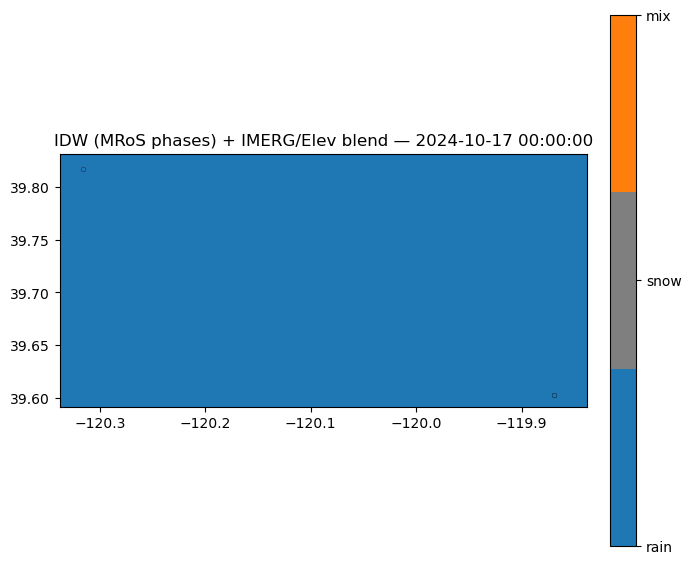

In [26]:
# ----------------------- Visualize  ---------------------
fig, ax = plt.subplots(figsize=(7,6))
cmap = ListedColormap(["tab:blue","tab:gray","tab:orange"])  # 0=rain,1=snow,2=mix
im = ax.imshow(cls_idx, origin="lower", extent=(xs.min(), xs.max(), ys.min(), ys.max()),
               cmap=cmap, vmin=0, vmax=2)
ax.scatter(pts["lon"], pts["lat"], s=12, edgecolors="k", linewidths=0.2)
ax.set_title(f"IDW (MRoS phases) + IMERG/Elev blend — {sample_hour}")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0,1,2])
cbar.ax.set_yticklabels(["rain","snow","mix"])
plt.tight_layout()
plt.show()